Симуляция динамики нейрона для различных значений токов...


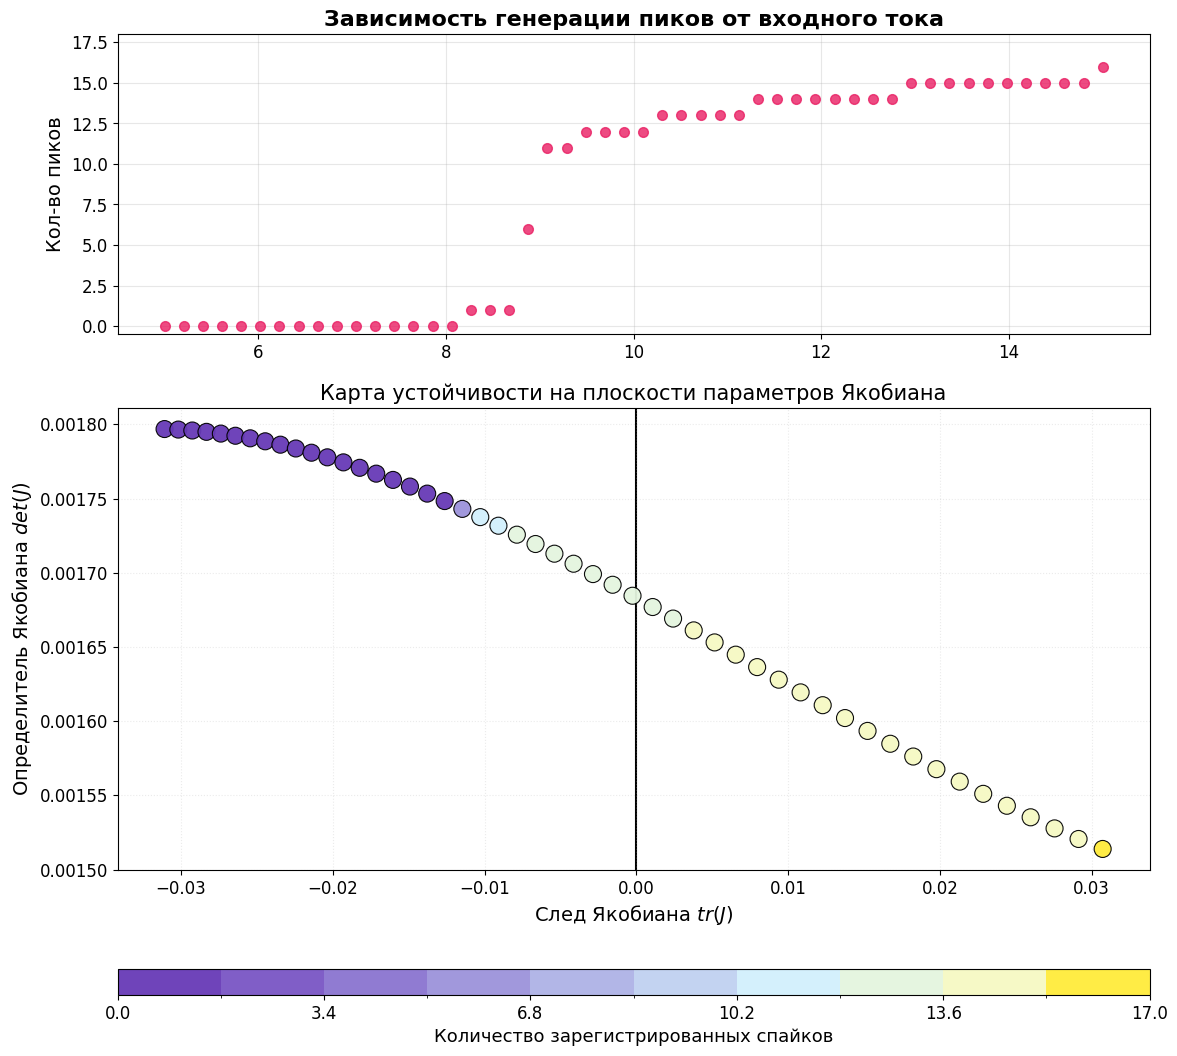

In [1]:
"""
Morris-Lecar Model: Stability Map on the Jacobian Trace-Determinant Plane.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.signal import find_peaks
from matplotlib.colors import ListedColormap, BoundaryNorm

# Настройка шрифтов для графиков по стандарту PEP-8 / публикации
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# Константы модели Морриса-Лекара
PARAMS = {
    'C': 20.0, 'g_leak': 0.20, 'V_leak': -50.0,
    'g_Ca': 4.4, 'V_Ca': 100.0, 'g_K': 8.0, 'V_K': -70.0,
    'V1': -1.0, 'V2': 15.0, 'V3': 2.0, 'V4': 30.0, 'phi': 0.05
}

def inf_m(V):
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def inf_Veq(V, I_hold):
    """Стационарное уравнение мембранных токов."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n_inf * (V - PARAMS['V_K'])
    return (-I_leak - I_Ca - I_K + I_hold) / PARAMS['C']

def DBolt(V5, V, k):
    """Производная функции Больцмана."""
    return np.exp((V5 - V) / k) / (k * (1 + np.exp((V5 - V) / k))**2)

def trJ(V):
    """След матрицы Якобиана."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    return -PARAMS['phi'] - (PARAMS['g_leak'] + PARAMS['g_K'] * n_inf +
             PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C']

def detJ(V):
    """Определитель матрицы Якобиана."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    Dn_inf = DBolt(PARAMS['V3'], V, PARAMS['V4'])
    return (PARAMS['g_leak'] + PARAMS['g_K'] * (n_inf + Dn_inf * (V - PARAMS['V_K'])) +
            PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C'] * PARAMS['phi']

def morris_lecar(t, y, I_func):
    """Правая часть системы ОДУ."""
    V, n = y
    I = I_func(t)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * inf_m(V) * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n * (V - PARAMS['V_K'])

    dVdt = (-I_leak - I_Ca - I_K + I) / PARAMS['C']
    dn_dt = PARAMS['phi'] * (inf_n(V) - n)
    return [dVdt, dn_dt]

def run_stability_analysis():
    # Начальные условия (состояние покоя при I=0)
    V0 = fsolve(lambda V: inf_Veq(V, 0.0), -60.0)[0]
    y0 = [V0, inf_n(V0)]

    I_currents = np.linspace(5.0, 15.0, 50)
    t_span = [0, 2000]
    t_eval = np.linspace(0, 2000, 10000)
    stim_period = t_eval > 100  # Анализ спайков после переходного процесса

    spike_counts = []
    trace_list = []
    det_list = []

    print("Симуляция динамики нейрона для различных значений токов...")
    for I in I_currents:
        def input_I(t):
            return np.where(t < 100, 0.0, I)

        sol = solve_ivp(lambda t, y: morris_lecar(t, y, input_I),
                        t_span, y0, t_eval=t_eval, method='LSODA', rtol=1e-6)

        # Вычисление количества пиков
        peaks, _ = find_peaks(sol.y[0][stim_period], height=0, distance=50)
        spike_counts.append(len(peaks))

        # Локализация точки равновесия и расчет Якобиана
        V_eq = fsolve(inf_Veq, -20.0, args=(I,), xtol=1e-6)[0]
        trace_list.append(trJ(V_eq))
        det_list.append(detJ(V_eq))

    # --- НАСТРОЙКА ЦВЕТОВОЙ ПАЛИТРЫ (CMAP) ---
    rgb_colors = [
        (103/255, 58/255, 183/255), (121/255, 85/255, 196/255),
        (138/255, 116/255, 208/255), (156/255, 147/255, 219/255),
        (174/255, 178/255, 230/255), (192/255, 209/255, 241/255),
        (210/255, 240/255, 252/255), (228/255, 245/255, 223/255),
        (246/255, 249/255, 195/255), (255/255, 235/255, 59/255),
    ]
    cmap = ListedColormap(rgb_colors)

    max_spikes = max(spike_counts) if max(spike_counts) > 0 else 1
    bounds = np.linspace(0, max_spikes + 1, len(rgb_colors) + 1)
    norm = BoundaryNorm(bounds, cmap.N)

    # --- ВИЗУАЛИЗАЦИЯ ---
    fig = plt.figure(figsize=(12, 11))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.2])

    ax_top = fig.add_subplot(gs[0, 0])
    ax_bottom = fig.add_subplot(gs[1, 0])

    # Верхний график: Число спайков от тока
    ax_top.plot(I_currents, spike_counts, 'o', color='#E91E63', markersize=7, alpha=0.8)
    ax_top.set_ylabel('Кол-во пиков', fontsize=14)
    ax_top.set_title('Зависимость генерации пиков от входного тока', fontsize=16, fontweight='bold')
    ax_top.grid(True, alpha=0.3)
    ax_top.set_ylim(-0.5, max_spikes + 2)

    # Нижний график: Плоскость Trace-Determinant
    sc = ax_bottom.scatter(trace_list, det_list, c=spike_counts, cmap=cmap, norm=norm,
                           s=150, edgecolors='black', linewidths=0.8, alpha=0.95, zorder=3)

    # Добавление цветовой шкалы
    cb = plt.colorbar(sc, ax=ax_bottom, orientation='horizontal', pad=0.15, aspect=40)
    cb.set_label('Количество зарегистрированных спайков', fontsize=13)

    # Оси координат (Границы устойчивости)
    ax_bottom.axhline(0, color='black', linewidth=1.5, zorder=1)
    ax_bottom.axvline(0, color='black', linewidth=1.5, zorder=1)
    ax_bottom.scatter([0], [0], color='black', s=50, zorder=4)

    ax_bottom.set_xlabel('След Якобиана $tr(J)$', fontsize=14)
    ax_bottom.set_ylabel('Определитель Якобиана $det(J)$', fontsize=14)
    ax_bottom.set_title('Карта устойчивости на плоскости параметров Якобиана', fontsize=15)
    ax_bottom.grid(True, alpha=0.25, linestyle=':')

    # Динамические отступы осей
    padx = 0.05 * (max(trace_list) - min(trace_list)) if max(trace_list) != min(trace_list) else 1
    pady = 0.05 * (max(det_list) - min(det_list)) if max(det_list) != min(det_list) else 1
    ax_bottom.set_xlim(min(trace_list) - padx, max(trace_list) + padx)
    ax_bottom.set_ylim(min(det_list) - pady, max(det_list) + pady)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_stability_analysis()